# Midori-64 Cipher

## Overview 
- **Cipher**: MIDORI is an energy-efficient lightweight block cipher designed to minimize the energy consumption per bit, making it ideal for IoT and battery-powered devices.
- **Models used**: Logistic Regression, MLP, CNN
- **Analysis done through**: Bitwise accuracy, Hamming distance, Generalization

## 1.Setup and Imports

In [1]:
from __future__ import annotations

import os
import pickle
import hashlib
import time
import warnings
import torch
import sklearn

warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.cuda.amp as amp
import matplotlib
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler

# Directories
os.makedirs("data/cache_midori",     exist_ok=True)
os.makedirs("data/cache_midori_gen", exist_ok=True)
os.makedirs("results_midori/models", exist_ok=True)

CACHE_DIR_DEFAULT = "data/cache_midori"

# Device setup
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = (DEVICE.type == "cuda")
print(f"Device  : {DEVICE}")

Device  : cuda


## 2. Midori Cipher Implementation

MIDORI is an energy-efficient lightweight block cipher

  Block size  : 64 bits  
  Key size    : 128 bits
  Full rounds : 16
  Structure   : SPN with energy-optimized components

In [2]:

BLOCK_BITS  = 64
KEY_BITS    = 128
FULL_ROUNDS = 16
CELLS       = 16    # 4x4 nibble matrix

# Two S-boxes (4-bit) 

SB0 = [0xC, 0xA, 0xD, 0x3, 0xE, 0xB, 0xF, 0x7,
       0x8, 0x9, 0x1, 0x5, 0x0, 0x2, 0x4, 0x6]

SB1 = [0x1, 0x0, 0x5, 0x3, 0xE, 0x2, 0xF, 0x7,
       0xD, 0xA, 0x9, 0xB, 0xC, 0x8, 0x4, 0x6]

SB0_INV = [0] * 16
SB1_INV = [0] * 16
for _i, _v in enumerate(SB0): SB0_INV[_v] = _i
for _i, _v in enumerate(SB1): SB1_INV[_v] = _i

SHUFFLE = [0, 10, 5, 15, 14, 4, 11, 1, 9, 3, 12, 6, 7, 13, 2, 8]

SHUFFLE_INV = [0] * 16
for _i, _v in enumerate(SHUFFLE): SHUFFLE_INV[_v] = _i

MIXCOL_M = [
    [0, 1, 1, 1],
    [1, 0, 1, 1],
    [1, 1, 0, 1],
    [1, 1, 1, 0],
]

ROUND_CONSTANTS = [
    0x0001010110110011,
    0x0110000001000001,
    0x0111011100100010,
    0x0100001101100000,
    0x1001010001000110,
    0x1111011010010000,
    0x0101000100100000,
    0x0010011001000001,
    0x0001000010110010,
    0x0000101111001100,
    0x1001001001100110,
    0x1000010000010011,
    0x0110001100010000,
    0x0011010010010100,
    0x0001010100000001,
    0x0000000000000000,  
]


In [3]:
#helpers

def _gc(s: int, i: int) -> int:

    return (s >> (60 - 4 * i)) & 0xF

def _sc(s: int, i: int, v: int) -> int:

    sh = 60 - 4 * i
    return (s & ~(0xF << sh)) | ((v & 0xF) << sh)

def _s2c(s: int) -> list[int]:
    return [_gc(s, i) for i in range(CELLS)]

def _c2s(cells: list[int]) -> int:
    s = 0
    for i, v in enumerate(cells):
        s = _sc(s, i, v)
    return s


# Layer functions 

def _sub_cells(state: int, sbox: list) -> int:

    r = 0
    for i in range(CELLS):
        r = _sc(r, i, sbox[_gc(state, i)])
    return r


def _shuffle_cells(state: int, perm: list) -> int:

    cells = _s2c(state)
    out   = [0] * CELLS
    for i in range(CELLS):
        out[perm[i]] = cells[i]
    return _c2s(out)


def _mix_columns(state: int) -> int:

    r = 0
    for col in range(4):
        col_in = [_gc(state, row * 4 + col) for row in range(4)]
        total  = col_in[0] ^ col_in[1] ^ col_in[2] ^ col_in[3]
        for row in range(4):
            # out[row] = XOR of all except row = total XOR col_in[row]
            r = _sc(r, row * 4 + col, total ^ col_in[row])
    return r


def _add_round_key(state: int, rk: int) -> int:

    return state ^ rk


# Key schedule 

def _key_schedule(key: int, num_rounds: int) -> tuple[int, int, list[int]]:

    WK0 = (key >> 64) & 0xFFFFFFFFFFFFFFFF
    WK1 =  key        & 0xFFFFFFFFFFFFFFFF

    round_keys = []
    for i in range(num_rounds):
        wk = WK0 if (i % 2 == 0) else WK1
        round_keys.append(wk ^ ROUND_CONSTANTS[i])

    return WK0, WK1, round_keys


#  Encrypt / Decrypt 

def midori_encrypt(plaintext: int, key: int,
                   num_rounds: int = FULL_ROUNDS) -> int:

    assert 0 <= plaintext < (1 << BLOCK_BITS), "Plaintext must be 64-bit"
    assert 0 <= key        < (1 << KEY_BITS),  "Key must be 128-bit"
    assert 1 <= num_rounds <= FULL_ROUNDS,      f"Rounds must be in [1, {FULL_ROUNDS}]"

    WK0, WK1, round_keys = _key_schedule(key, num_rounds)

    state = plaintext ^ WK0 ^ WK1

    for r in range(num_rounds):

        sbox  = SB1 if (r % 2 == 0) else SB0
        state = _sub_cells(state, sbox)
        state = _shuffle_cells(state, SHUFFLE)
        state = _mix_columns(state)
        state = _add_round_key(state, round_keys[r])


    final_sbox = SB1 if (num_rounds % 2 == 0) else SB0
    state = _sub_cells(state, final_sbox)

    state ^= WK0 ^ WK1

    return state & 0xFFFFFFFFFFFFFFFF


def midori_decrypt(ciphertext: int, key: int,
                   num_rounds: int = FULL_ROUNDS) -> int:

    assert 0 <= ciphertext < (1 << BLOCK_BITS)
    assert 0 <= key         < (1 << KEY_BITS)
    assert 1 <= num_rounds  <= FULL_ROUNDS

    WK0, WK1, round_keys = _key_schedule(key, num_rounds)

    state = ciphertext ^ WK0 ^ WK1

    final_sbox_inv = SB1_INV if (num_rounds % 2 == 0) else SB0_INV
    state = _sub_cells(state, final_sbox_inv)

    for r in range(num_rounds - 1, -1, -1):
        state = _add_round_key(state, round_keys[r])
        state = _mix_columns(state)          # M is self-inverse
        state = _shuffle_cells(state, SHUFFLE_INV)
        sbox_inv = SB1_INV if (r % 2 == 0) else SB0_INV
        state = _sub_cells(state, sbox_inv)

    state ^= WK0 ^ WK1

    return state & 0xFFFFFFFFFFFFFFFF

class MidoriCipher:

    BLOCK_BITS = 64
    KEY_BITS   = 128

    def __init__(self, key: int, num_rounds: int = FULL_ROUNDS):
        assert 0 <= key < (1 << self.KEY_BITS), "Key must be 128-bit"
        assert 1 <= num_rounds <= FULL_ROUNDS
        self.key        = key
        self.num_rounds = num_rounds

    def encrypt(self, plaintext: int) -> int:
        return midori_encrypt(plaintext, self.key, self.num_rounds)

    def decrypt(self, ciphertext: int) -> int:
        return midori_decrypt(ciphertext, self.key, self.num_rounds)

## 3.Dataset Generation

Dataset generation for MIDORI-64 : reduced-round learning

In [4]:


def _batch_bits(values: np.ndarray, num_bits: int) -> np.ndarray:
    shifts = np.arange(num_bits - 1, -1, -1, dtype=np.int64)
    return ((values[:, None] >> shifts) & 1).astype(np.float32)


def generate_dataset(num_rounds, num_samples, key, seed=42,
                     cache_dir=CACHE_DIR_DEFAULT):
    os.makedirs(cache_dir, exist_ok=True)
    tag  = hashlib.md5(f"midori_{num_rounds}_{num_samples}_{key}_{seed}".encode()).hexdigest()[:10]
    path = os.path.join(cache_dir, f"midori_r{num_rounds}_{tag}.pkl")

    if os.path.exists(path):
        with open(path, "rb") as f: X, y = pickle.load(f)
        print(f"[Dataset] Loaded: {path}"); return X, y

    rng    = np.random.default_rng(seed)
    cipher = MidoriCipher(key, num_rounds)
    hi = rng.integers(0, 1 << 32, size=num_samples, dtype=np.int64)
    lo = rng.integers(0, 1 << 32, size=num_samples, dtype=np.int64)
    pts = (hi << 32) | lo
    X   = _batch_bits(pts, BLOCK_BITS)
    y   = np.array(
        [[(cipher.encrypt(int(p) & 0xFFFFFFFFFFFFFFFF) >> (63 - i)) & 1
          for i in range(BLOCK_BITS)]
         for p in pts], dtype=np.float32
    )
    with open(path, "wb") as f: pickle.dump((X, y), f)
    print(f"[Dataset] Cached: {path}"); return X, y


def build_all_datasets(round_list, num_samples, key,
                       val_split=0.15, test_split=0.15,
                       seed=42, cache_dir=CACHE_DIR_DEFAULT):
    datasets = {}
    rng = np.random.default_rng(seed)
    nv = int(num_samples * val_split)
    nt = int(num_samples * test_split)
    nr = num_samples - nv - nt
    for r in round_list:
        print(f"\n[Dataset] round={r} ...")
        X, y = generate_dataset(r, num_samples, key, seed=seed, cache_dir=cache_dir)
        idx  = rng.permutation(num_samples)
        datasets[r] = {
            "X_train": X[idx[:nr]],       "y_train": y[idx[:nr]],
            "X_val":   X[idx[nr:nr+nv]],  "y_val":   y[idx[nr:nr+nv]],
            "X_test":  X[idx[nr+nv:]],    "y_test":  y[idx[nr+nv:]],
        }
    return datasets


In [5]:
KEY         = 0x0123456789ABCDEFFEDCBA9876543210
ROUND_LIST  = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16]
NUM_SAMPLES = 30_000
EPOCHS      = 50
BATCH_SIZE  = 512
LR          = 2e-3
PATIENCE    = 6
SEED        = 42

RESULTS_DIR = "results_midori"
MODELS_DIR  = "results_midori/models"
DATA_DIR    = "data/cache_midori"

COLORS = {"lr":"#e74c3c","mlp":"#2980b9","cnn":"#27ae60"}
LABELS = {"lr":"Logistic Regression","mlp":"MLP","cnn":"CNN"}
RANDOM_BITACC  = 0.50
RANDOM_HAMMING = 32.0
LEARN_THRESHOLD = 0.55


print(f"Configuration:")
print(f"  Samples : {NUM_SAMPLES:,}")
print(f"  Epochs  : {EPOCHS}")
print(f"  Batch   : {BATCH_SIZE}")
print(f"  Rounds  : {ROUND_LIST}")

Configuration:
  Samples : 30,000
  Epochs  : 50
  Batch   : 512
  Rounds  : [1, 2, 3, 4, 5, 6, 8, 10, 12, 16]


In [6]:
print("Building datasets ...")
t0 = time.time()

datasets = build_all_datasets(
    round_list=ROUND_LIST,
    num_samples=NUM_SAMPLES,
    key=KEY,
    seed=SEED,
    cache_dir=DATA_DIR
)

r0 = ROUND_LIST[0]
print(f"\nSample shapes for r={r0}:")
print(f"  X_train : {datasets[r0]['X_train'].shape}")
print(f"  y_train : {datasets[r0]['y_train'].shape}")
print(f"  X_val   : {datasets[r0]['X_val'].shape}")
print(f"  X_test  : {datasets[r0]['X_test'].shape}")


Building datasets ...

[Dataset] round=1 ...
[Dataset] Loaded: data/cache_midori\midori_r1_ed0d8478d4.pkl

[Dataset] round=2 ...
[Dataset] Loaded: data/cache_midori\midori_r2_9c0de373f9.pkl

[Dataset] round=3 ...
[Dataset] Loaded: data/cache_midori\midori_r3_ee98cf04ce.pkl

[Dataset] round=4 ...
[Dataset] Loaded: data/cache_midori\midori_r4_89787c7503.pkl

[Dataset] round=5 ...
[Dataset] Loaded: data/cache_midori\midori_r5_a64c9a783f.pkl

[Dataset] round=6 ...
[Dataset] Loaded: data/cache_midori\midori_r6_3fecbfc76e.pkl

[Dataset] round=8 ...
[Dataset] Loaded: data/cache_midori\midori_r8_2b0053e986.pkl

[Dataset] round=10 ...
[Dataset] Loaded: data/cache_midori\midori_r10_b0248b7b0b.pkl

[Dataset] round=12 ...
[Dataset] Loaded: data/cache_midori\midori_r12_68fd259412.pkl

[Dataset] round=16 ...
[Dataset] Loaded: data/cache_midori\midori_r16_59b328b6c9.pkl

Sample shapes for r=1:
  X_train : (21000, 64)
  y_train : (21000, 64)
  X_val   : (4500, 64)
  X_test  : (4500, 64)


## 4. Model Definations


Three models are implemented and compared:
1. **Logistic Regression** — Linear baseline (scikit-learn)
2. **MLP** — Residual MLP (128 → 512 → 512+skip → 256 → 128)
3. **CNN** — Dilated 1-D CNN (captures sparse tap structure of Grain-128)

In [7]:

class LogisticRegressionModel:
    def __init__(self, max_iter=2000, C=1.0):
        self.model  = MultiOutputClassifier(
            LogisticRegression(max_iter=max_iter, C=C, solver="lbfgs"), n_jobs=-1)
        self.scaler = StandardScaler()

    def fit(self, X, y, Xv=None, yv=None):
        self.model.fit(self.scaler.fit_transform(X), y.astype(int)); return {}

    def predict_proba(self, X):
        return np.stack([p[:,1] for p in self.model.predict_proba(self.scaler.transform(X))], 1)

    def predict(self, X): return (self.predict_proba(X)>=0.5).astype(np.float32)

    def evaluate(self, X, y):
        p=self.predict(X)
        return {"bitwise_accuracy":float(np.mean(p==y)),
                "mean_hamming":float(np.mean(np.sum(np.abs(p-y),1))),
                "exact_match":float(np.mean(np.all(p==y,1)))}

    def save(self, path):
        os.makedirs(os.path.dirname(path),exist_ok=True)
        joblib.dump({"model":self.model,"scaler":self.scaler}, path)

    def load(self, path):
        o=joblib.load(path); self.model,self.scaler=o["model"],o["scaler"]


class MLPNet(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.b1=nn.Sequential(nn.Linear(64,512), nn.BatchNorm1d(512), nn.GELU(),nn.Dropout(dropout))
        self.b2=nn.Sequential(nn.Linear(512,1024),nn.BatchNorm1d(1024),nn.GELU(),nn.Dropout(dropout))
        self.b3=nn.Sequential(nn.Linear(1024,1024),nn.BatchNorm1d(1024),nn.GELU(),nn.Dropout(dropout))
        self.b4=nn.Sequential(nn.Linear(1024,512),nn.BatchNorm1d(512), nn.GELU(),nn.Dropout(dropout))
        self.proj=nn.Linear(64,1024); self.head=nn.Linear(512,64)

    def forward(self,x):
        h=self.b1(x); h=self.b2(h); h=self.b3(h)+self.proj(x); h=self.b4(h)
        return self.head(h)


class CNNNet(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        def blk(ic,oc,k,d):
            return nn.Sequential(
                nn.Conv1d(ic,oc,k,padding=(k//2)*d,dilation=d),
                nn.BatchNorm1d(oc),nn.GELU(),nn.Dropout(dropout))
        self.convs=nn.Sequential(blk(1,64,5,1),blk(64,128,5,2),blk(128,256,5,4),blk(256,128,3,1))
        self.gap=nn.AdaptiveAvgPool1d(1)
        self.head=nn.Sequential(nn.Linear(128,256),nn.GELU(),nn.Dropout(dropout),nn.Linear(256,64))

    def forward(self,x):
        x=x.unsqueeze(1); x=self.convs(x); x=self.gap(x).squeeze(2); return self.head(x)


def _make_trainer(NetClass):
    class Model:
        def __init__(self, dropout=0.25, lr=2e-3, weight_decay=1e-4,
                     batch_size=512, epochs=50, patience=6):
            self.dropout=dropout; self.lr=lr; self.wd=weight_decay
            self.bs=batch_size; self.epochs=epochs; self.patience=patience; self.net=None

        def _build(self):
            self.net=NetClass(self.dropout).to(DEVICE)
            self.opt=torch.optim.AdamW(self.net.parameters(),lr=self.lr,weight_decay=self.wd)
            self.sch=torch.optim.lr_scheduler.CosineAnnealingLR(self.opt,T_max=self.epochs)
            self.lf=nn.BCEWithLogitsLoss()
            self.sc=torch.cuda.amp.GradScaler(enabled=(DEVICE.type=="cuda"))

        def _t(self,a): 
            return torch.tensor(a,dtype=torch.float32)

        def fit(self,X,y,Xv=None,yv=None):
            self._build()
            ds=torch.utils.data.TensorDataset(self._t(X),self._t(y))
            dl=torch.utils.data.DataLoader(ds,batch_size=self.bs,shuffle=True,
               num_workers=0,pin_memory=False,persistent_workers=False)
            bv=0.0; bs=None; ni=0
            for ep in range(1,self.epochs+1):
                self.net.train(); tl=0.0
                for xb,yb in dl:
                    xb,yb=xb.to(DEVICE,non_blocking=True),yb.to(DEVICE,non_blocking=True)
                    self.opt.zero_grad(set_to_none=True)
                    with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
                        loss=self.lf(self.net(xb),yb)
                    self.sc.scale(loss).backward(); self.sc.step(self.opt); self.sc.update()
                    tl+=loss.item()*len(xb)
                self.sch.step()
                if Xv is not None:
                    va=self.evaluate(Xv,yv)["bitwise_accuracy"]
                    if ep%10==0: print(f"  Ep {ep:3d}/{self.epochs} loss={tl/len(X):.4f} val={va:.4f}")
                    if va>bv+1e-4: bv=va; bs={k:v.clone() for k,v in self.net.state_dict().items()}; ni=0
                    else:
                        ni+=1
                        if ni>=self.patience: print(f"  Early stop ep={ep}"); break
            if bs: self.net.load_state_dict(bs)

        @torch.no_grad()
        def predict_proba(self,X):
            self.net.eval()
            X_tensor = self._t(X).to(DEVICE)
            return torch.sigmoid(self.net(X_tensor)).cpu().numpy()
                    

        def predict(self,X): return (self.predict_proba(X)>=0.5).astype(np.float32)

        def evaluate(self,X,y):
            p=self.predict(X)
            return {"bitwise_accuracy":float(np.mean(p==y)),
                    "mean_hamming":float(np.mean(np.sum(np.abs(p-y),1))),
                    "exact_match":float(np.mean(np.all(p==y,1)))}

        def save(self,path):
            os.makedirs(os.path.dirname(path),exist_ok=True)
            torch.save(self.net.state_dict(),path)

        def load(self,path):
            self._build(); self.net.load_state_dict(torch.load(path,map_location=DEVICE))

    return Model

MLPModel = _make_trainer(MLPNet)
CNNModel = _make_trainer(CNNNet)


## 5. Training

In [8]:
def make_loader(X, y, shuffle=True):
    ds = torch.utils.data.TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return torch.utils.data.DataLoader(
        ds,
        batch_size          = BATCH_SIZE,
        shuffle             = shuffle,
        num_workers         = 0,
        pin_memory          = False,
        persistent_workers  = False,
    )


def train_lr(data):

    sc=StandardScaler(); Xs=sc.fit_transform(data["X_train"])
    m=MultiOutputClassifier(LogisticRegression(max_iter=500,C=1.0,solver="lbfgs"),n_jobs=-1)
    m.fit(Xs,data["y_train"].astype(int))
    pr=np.stack([p[:,1] for p in m.predict_proba(sc.transform(data["X_test"]))],1)
    pred=(pr>=0.5).astype(np.float32)
    return {"bitwise_accuracy":float(np.mean(pred==data["y_test"])),
            "mean_hamming":float(np.mean(np.sum(np.abs(pred-data["y_test"]),1))),
            "exact_match":float(np.mean(np.all(pred==data["y_test"],1)))}


def train_neural(ModelClass, data):
    m=ModelClass(epochs=EPOCHS,batch_size=BATCH_SIZE,lr=LR,patience=PATIENCE)
    t0=time.time()
    m.fit(data["X_train"],data["y_train"],data["X_val"],data["y_val"])
    metrics=m.evaluate(data["X_test"],data["y_test"])
    metrics["train_time_s"]=time.time()-t0
    return m, metrics



In [9]:
all_results={"lr":{},"mlp":{},"cnn":{}}

print("\n── Logistic Regression ──")
for r in ROUND_LIST:
    t=time.time(); metrics=train_lr(datasets[r])
    all_results["lr"][r]=metrics
    print(f"  r={r:2d} | bitacc={metrics['bitwise_accuracy']:.4f} | {time.time()-t:.1f}s")



── Logistic Regression ──
  r= 1 | bitacc=0.5020 | 11.4s
  r= 2 | bitacc=0.5006 | 0.7s
  r= 3 | bitacc=0.4986 | 0.7s
  r= 4 | bitacc=0.4994 | 0.7s
  r= 5 | bitacc=0.4989 | 0.7s
  r= 6 | bitacc=0.5005 | 0.7s
  r= 8 | bitacc=0.4999 | 0.7s
  r=10 | bitacc=0.5000 | 0.7s
  r=12 | bitacc=0.5015 | 0.7s
  r=16 | bitacc=0.5002 | 0.7s


In [10]:

print("\n── MLP ──")
for r in ROUND_LIST:
    print(f"\n  rounds={r}")
    model,metrics=train_neural(MLPModel,datasets[r])
    all_results["mlp"][r]=metrics
    if model.net: torch.save(model.net.state_dict(),os.path.join(MODELS_DIR,f"mlp_r{r}.pt"))
    print(f"  → bitacc={metrics['bitwise_accuracy']:.4f}  time={metrics['train_time_s']:.1f}s")
  


── MLP ──

  rounds=1
  Early stop ep=8
  → bitacc=0.5002  time=9.3s

  rounds=2
  Ep  10/50 loss=0.6849 val=0.5001
  Early stop ep=11
  → bitacc=0.5007  time=6.8s

  rounds=3
  Ep  10/50 loss=0.6853 val=0.5000
  Early stop ep=14
  → bitacc=0.4995  time=8.0s

  rounds=4
  Ep  10/50 loss=0.6853 val=0.5003
  Early stop ep=10
  → bitacc=0.5007  time=5.7s

  rounds=5
  Early stop ep=8
  → bitacc=0.5009  time=4.1s

  rounds=6
  Early stop ep=9
  → bitacc=0.5001  time=4.8s

  rounds=8
  Ep  10/50 loss=0.6853 val=0.5008
  Early stop ep=13
  → bitacc=0.5008  time=6.6s

  rounds=10
  Early stop ep=9
  → bitacc=0.4984  time=4.8s

  rounds=12
  Early stop ep=8
  → bitacc=0.5011  time=4.9s

  rounds=16
  Ep  10/50 loss=0.6853 val=0.4999
  Early stop ep=12
  → bitacc=0.5013  time=6.4s


In [11]:

print("\n── CNN ──")
for r in ROUND_LIST:
    print(f"\n  rounds={r}")
    model,metrics=train_neural(CNNModel,datasets[r])
    all_results["cnn"][r]=metrics
    if model.net: torch.save(model.net.state_dict(),os.path.join(MODELS_DIR,f"cnn_r{r}.pt"))
    print(f"   bitacc={metrics['bitwise_accuracy']:.4f}  time={metrics['train_time_s']:.1f}s")



── CNN ──

  rounds=1
  Early stop ep=9
   bitacc=0.4993  time=9.1s

  rounds=2
  Early stop ep=7
   bitacc=0.4980  time=7.1s

  rounds=3
  Early stop ep=7
   bitacc=0.4991  time=7.4s

  rounds=4
  Early stop ep=9
   bitacc=0.5004  time=12.3s

  rounds=5
  Ep  10/50 loss=0.6930 val=0.5004
  Early stop ep=17
   bitacc=0.4993  time=17.3s

  rounds=6
  Early stop ep=8
   bitacc=0.5005  time=8.9s

  rounds=8
  Early stop ep=7
   bitacc=0.4988  time=7.4s

  rounds=10
  Ep  10/50 loss=0.6930 val=0.4997
  Early stop ep=12
   bitacc=0.4998  time=12.5s

  rounds=12
  Ep  10/50 loss=0.6930 val=0.4996
  Early stop ep=10
   bitacc=0.4996  time=11.1s

  rounds=16
  Ep  10/50 loss=0.6930 val=0.5008
  Early stop ep=11
   bitacc=0.4992  time=11.1s


## 6. Avalanche Effect Analysis

In [12]:
import random as rnd
print("Computing avalanche effect ...")
rnd.seed(0)
avg_diffs=[]

for r in ROUND_LIST:
    diffs = []
    c = MidoriCipher(KEY, r)

    for _ in range(2000):
        pt1 = rnd.randint(0, (1 << 64) - 1)
        pt2 = pt1 ^ (1 << rnd.randint(0, 63))

        diff = c.encrypt(pt1) ^ c.encrypt(pt2)
        diffs.append(bin(diff).count("1"))

    avg = sum(diffs) / len(diffs)
    avg_diffs.append(avg)
    print(f"r={r:2d} | avg diff bits = {avg:.2f}/64 (ideal=32)")


plt.figure(figsize=(8, 4))
plt.plot(ROUND_LIST, avg_diffs, marker="o", linewidth=2)
plt.axhline(32, linestyle="--", label="Ideal (32 bits)")
plt.xlabel("Rounds")
plt.ylabel("Avg Differing Bits")
plt.title("MIDORI-64 Avalanche Effect")
plt.legend()
plt.grid(True)
path = os.path.join(RESULTS_DIR, "avalanche.png")
plt.savefig(path, dpi=150)
plt.close()
print(f"[Plot] saved → {path}")

Computing avalanche effect ...
r= 1 | avg diff bits = 5.90/64 (ideal=32)
r= 2 | avg diff bits = 18.62/64 (ideal=32)
r= 3 | avg diff bits = 32.44/64 (ideal=32)
r= 4 | avg diff bits = 32.14/64 (ideal=32)
r= 5 | avg diff bits = 32.01/64 (ideal=32)
r= 6 | avg diff bits = 31.89/64 (ideal=32)
r= 8 | avg diff bits = 32.06/64 (ideal=32)
r=10 | avg diff bits = 32.08/64 (ideal=32)
r=12 | avg diff bits = 32.04/64 (ideal=32)
r=16 | avg diff bits = 31.84/64 (ideal=32)
[Plot] saved → results_midori\avalanche.png


## 7. Results

In [13]:

print("=" * 72)
print("  Midori64  BITWISE ACCURACY SUMMARY")
print(f"  {'Rounds':>8}  {'LR Acc':>10}  {'MLP Acc':>10}  {'CNN Acc':>10}  {'Best':>12}")
print("-" * 72)
for r in ROUND_LIST:
    lr_a  = all_results["lr" ][r]["bitwise_accuracy"]
    mlp_a = all_results["mlp"][r]["bitwise_accuracy"]
    cnn_a = all_results["cnn"][r]["bitwise_accuracy"]
    best  = max(lr_a, mlp_a, cnn_a)
    bname = ["LR","MLP","CNN"][[lr_a,mlp_a,cnn_a].index(best)]

    print(f"  {r:>8}  {lr_a:>10.4f}  {mlp_a:>10.4f}  {cnn_a:>10.4f}  {bname} {best:.4f}")
print("=" * 72)


# Learnability analysis
print(f"\n[Analysis] Max learnable rounds (bitacc > {LEARN_THRESHOLD}):")
for m_name, res in all_results.items():
    learnable = [r for r in ROUND_LIST if res[r]["bitwise_accuracy"] > LEARN_THRESHOLD]
    mx = max(learnable) if learnable else 0
    print(f"  {LABELS[m_name]:25s}: max r = {mx}")

  Midori64  BITWISE ACCURACY SUMMARY
    Rounds      LR Acc     MLP Acc     CNN Acc          Best
------------------------------------------------------------------------
         1      0.5020      0.5002      0.4993  LR 0.5020
         2      0.5006      0.5007      0.4980  MLP 0.5007
         3      0.4986      0.4995      0.4991  MLP 0.4995
         4      0.4994      0.5007      0.5004  MLP 0.5007
         5      0.4989      0.5009      0.4993  MLP 0.5009
         6      0.5005      0.5001      0.5005  LR 0.5005
         8      0.4999      0.5008      0.4988  MLP 0.5008
        10      0.5000      0.4984      0.4998  LR 0.5000
        12      0.5015      0.5011      0.4996  LR 0.5015
        16      0.5002      0.5013      0.4992  MLP 0.5013

[Analysis] Max learnable rounds (bitacc > 0.55):
  Logistic Regression      : max r = 0
  MLP                      : max r = 0
  CNN                      : max r = 0


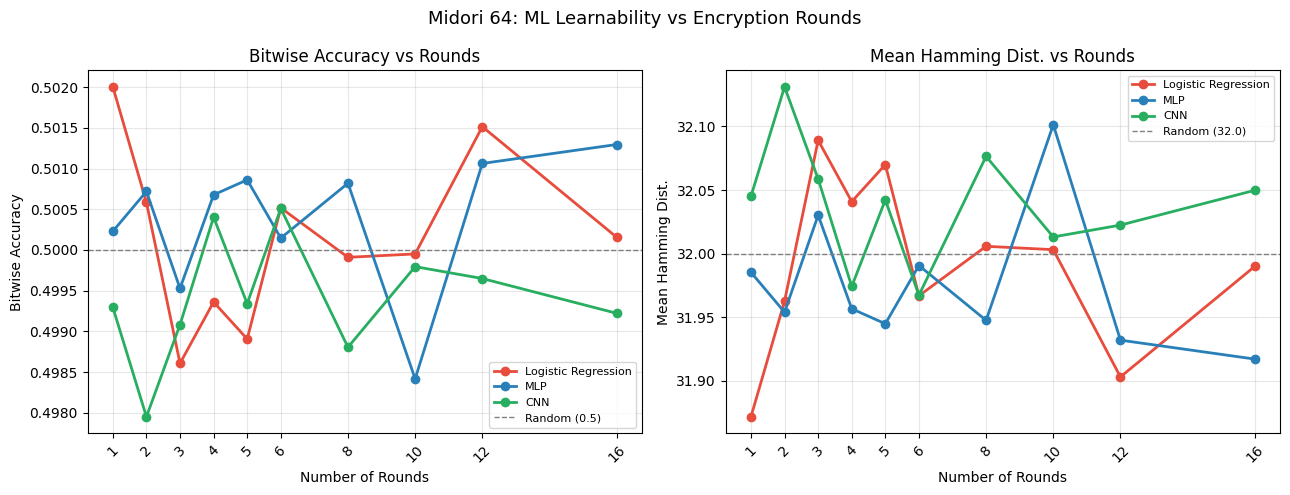

[Plot] Saved : results_midori/combined_metrics.png


In [14]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metric_cfg = [
    ("bitwise_accuracy", "Bitwise Accuracy",   RANDOM_BITACC),
    ("mean_hamming",     "Mean Hamming Dist.",  RANDOM_HAMMING),
]

for ax, (metric, ylabel, hline) in zip(axes, metric_cfg):
    for m_name, res in all_results.items():
        vals = [res[r][metric] for r in ROUND_LIST]
        ax.plot(ROUND_LIST, vals, marker="o", linewidth=2,
                color=COLORS[m_name], label=LABELS[m_name])
    if hline is not None:
        ax.axhline(hline, color="gray", linestyle="--", linewidth=1,
                   label=f"Random ({hline})")
    ax.set_xlabel("Number of Rounds")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + " vs Rounds")
    ax.set_xticks(ROUND_LIST)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Midori 64: ML Learnability vs Encryption Rounds", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "combined_metrics.png"), dpi=150)
plt.show()
print(f"[Plot] Saved : results_midori/combined_metrics.png")

## 8. Generalization evaluation

In [15]:
NEW_SEED    = 999
NEW_SAMPLES = 5_000

def load_mlp_ckpt(r):
    path = os.path.join(MODELS_DIR, f"mlp_r{r}.pt")
    if not os.path.exists(path):
        return None
    m = MLPNet().to(DEVICE)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.eval()
    return m


@torch.no_grad()
def predict_model(model, X):
    Xt   = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    prob = torch.sigmoid(model(Xt)).cpu().numpy()
    return (prob >= 0.5).astype(np.float32), prob


print(f"Generalisation setup:")
print(f"  New seed    : {NEW_SEED}  (training used seed={SEED})")
print(f"  New samples : {NEW_SAMPLES:,} fresh plaintexts")

Generalisation setup:
  New seed    : 999  (training used seed=42)
  New samples : 5,000 fresh plaintexts


In [16]:

gen_results = {}

print("=" * 60)
print("  Midori 64 Generalisation (Unseen Plaintexts)")
print("=" * 60)

for r in ROUND_LIST:
    print(f"\n  r = {r}")

    X_new, y_new = generate_dataset(
        num_rounds  = r,
        num_samples = NEW_SAMPLES,
        key         = KEY,
        seed        = NEW_SEED,
        cache_dir   = "data/cache_midori_gen",
    )

    model = load_mlp_ckpt(r)
    if model is None:
        print(f"    No checkpoint found for r={r}")
        continue

    y_pred, prob = predict_model(model, X_new)
    bitacc  = float(np.mean(y_pred == y_new))
    hamming = float(np.mean(np.sum(np.abs(y_pred - y_new), axis=1)))
    exact   = float(np.mean(np.all(y_pred == y_new, axis=1)))

    gen_results[r] = {
        "bitwise_accuracy": bitacc,
        "mean_hamming":     hamming,
        "exact_match":      exact,
    }

    delta = bitacc - 0.50
   
    print(f"    Bitwise accuracy : {bitacc:.4f}  ({delta:+.4f} vs random)")
    print(f"    Mean Hamming     : {hamming:.2f} / 32 bits")
    print(f"    Exact match      : {exact:.6f}")

  Midori 64 Generalisation (Unseen Plaintexts)

  r = 1
[Dataset] Cached: data/cache_midori_gen\midori_r1_32939c3441.pkl
    Bitwise accuracy : 0.4999  (-0.0001 vs random)
    Mean Hamming     : 32.01 / 32 bits
    Exact match      : 0.000000

  r = 2
[Dataset] Cached: data/cache_midori_gen\midori_r2_c184102289.pkl
    Bitwise accuracy : 0.4997  (-0.0003 vs random)
    Mean Hamming     : 32.02 / 32 bits
    Exact match      : 0.000000

  r = 3
[Dataset] Cached: data/cache_midori_gen\midori_r3_ec830f5368.pkl
    Bitwise accuracy : 0.5011  (+0.0011 vs random)
    Mean Hamming     : 31.93 / 32 bits
    Exact match      : 0.000000

  r = 4
[Dataset] Cached: data/cache_midori_gen\midori_r4_27a531fb7c.pkl
    Bitwise accuracy : 0.5004  (+0.0004 vs random)
    Mean Hamming     : 31.98 / 32 bits
    Exact match      : 0.000000

  r = 5
[Dataset] Cached: data/cache_midori_gen\midori_r5_025a614b4d.pkl
    Bitwise accuracy : 0.4994  (-0.0006 vs random)
    Mean Hamming     : 32.04 / 32 bits
    E

In [17]:
print("\n" + "=" * 60)
print("  GENERALISATION SUMMARY  (MLP on unseen plaintexts)")
print("=" * 60)
print(f"  {'Rounds':>8}  {'BitAcc':>8}  {'Hamming':>9}  {'vs Random':>10}")
print(f"  {'─'*46}")
for r, m in gen_results.items():
    delta = m['bitwise_accuracy'] - 0.50
    
    print(f"  {r:>8}  {m['bitwise_accuracy']:>8.4f}  "
          f"{m['mean_hamming']:>9.2f}  {delta:>+10.4f}")
print("=" * 60)

if gen_results:
    print("\n  TRAIN (test split) vs GENERALISATION — MLP")
    print(f"  {'─'*52}")
    print(f"  {'Rounds':>8}  {'Train BitAcc':>13}  {'Gen BitAcc':>11}  {'Gap':>6}")
    print(f"  {'─'*52}")
    for r in ROUND_LIST:
        if r not in gen_results or r not in all_results["mlp"]:
            continue
        tr  = all_results["mlp"][r]["bitwise_accuracy"]
        ge  = gen_results[r]["bitwise_accuracy"]
        gap = tr - ge
        print(f"  {r:>8}  {tr:>13.4f}  {ge:>11.4f}  {gap:>+6.4f}")
    print("\n  Gap ~ 0 : learnt cipher structure, not memorisation.")


  GENERALISATION SUMMARY  (MLP on unseen plaintexts)
    Rounds    BitAcc    Hamming   vs Random
  ──────────────────────────────────────────────
         1    0.4999      32.01     -0.0001
         2    0.4997      32.02     -0.0003
         3    0.5011      31.93     +0.0011
         4    0.5004      31.98     +0.0004
         5    0.4994      32.04     -0.0006
         6    0.4981      32.12     -0.0019
         8    0.4987      32.09     -0.0013
        10    0.5012      31.93     +0.0012
        12    0.4988      32.07     -0.0012
        16    0.4997      32.02     -0.0003

  TRAIN (test split) vs GENERALISATION — MLP
  ────────────────────────────────────────────────────
    Rounds   Train BitAcc   Gen BitAcc     Gap
  ────────────────────────────────────────────────────
         1         0.5002       0.4999  +0.0004
         2         0.5007       0.4997  +0.0011
         3         0.4995       0.5011  -0.0016
         4         0.5007       0.5004  +0.0003
         5        

## Summary

In [18]:

print("\n" + "=" * 78)
print("  FINAL RESULTS — Midori 64")
print("=" * 78)
print(f"  {'Rounds':>8} │ {'LR Acc':>8} │ {'MLP Acc':>8} │ {'CNN Acc':>8} │"
      f" {'LR Ham':>7} │ {'MLP Ham':>7} │ {'CNN Ham':>7}")
for r in ROUND_LIST:
    la = all_results["lr" ][r]["bitwise_accuracy"]
    ma = all_results["mlp"][r]["bitwise_accuracy"]
    ca = all_results["cnn"][r]["bitwise_accuracy"]
    lh = all_results["lr" ][r]["mean_hamming"]
    mh = all_results["mlp"][r]["mean_hamming"]
    ch = all_results["cnn"][r]["mean_hamming"]
    print(f"  {r:>8} │ {la:>8.4f} │ {ma:>8.4f} │ {ca:>8.4f} │"
          f" {lh:>7.2f} │ {mh:>7.2f} │ {ch:>7.2f}")



  FINAL RESULTS — Midori 64
    Rounds │   LR Acc │  MLP Acc │  CNN Acc │  LR Ham │ MLP Ham │ CNN Ham
         1 │   0.5020 │   0.5002 │   0.4993 │   31.87 │   31.99 │   32.05
         2 │   0.5006 │   0.5007 │   0.4980 │   31.96 │   31.95 │   32.13
         3 │   0.4986 │   0.4995 │   0.4991 │   32.09 │   32.03 │   32.06
         4 │   0.4994 │   0.5007 │   0.5004 │   32.04 │   31.96 │   31.97
         5 │   0.4989 │   0.5009 │   0.4993 │   32.07 │   31.94 │   32.04
         6 │   0.5005 │   0.5001 │   0.5005 │   31.97 │   31.99 │   31.97
         8 │   0.4999 │   0.5008 │   0.4988 │   32.01 │   31.95 │   32.08
        10 │   0.5000 │   0.4984 │   0.4998 │   32.00 │   32.10 │   32.01
        12 │   0.5015 │   0.5011 │   0.4996 │   31.90 │   31.93 │   32.02
        16 │   0.5002 │   0.5013 │   0.4992 │   31.99 │   31.92 │   32.05
